In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df=pd.read_csv('~/Downloads/2042763_ejection_results.txt', header=None)

In [4]:
df

,0,1,2,3
0,0.00005,23000.0,1401604,Ejected
1,0.00005,75000.0,3144845,Captured
2,0.00005,141000.0,1358187,Ejected
3,0.00005,138000.0,1358188,Ejected
4,0.00005,192000.0,3400312,Ejected
...,...,...,...,...
21546,0.10000,13000.0,249538,Captured
21547,0.10000,14000.0,249523,Captured
21548,0.10000,13000.0,249531,Captured
21549,0.10000,23000.0,1373552,Captured


In [23]:
df.columns=['mass','time','particle_id','result']

ValueError: Length mismatch: Expected axis has 2 elements, new values have 4 elements

In [ ]:
N=[4500,4500,4500,4500,4500,4500,4500,4500,4500]

In [ ]:
masses=df.mass.unique()

In [ ]:
masses

array([5.00000e-05, 1.00000e-04, 3.00270e-04, 7.12060e-04, 1.68856e-03,
       4.00422e-03, 9.49550e-03, 3.00270e-02, 1.00000e-01])

In [ ]:

def compute_cumulative_outcome_fractions(df, masses, N):
    """
    df      : DataFrame with columns ['mass', 'time', 'particle_id', 'result']
              where result is 'Ejected' or 'Captured', and each row represents
              the time at which that particle's outcome occurred
    masses  : list/array of unique mass values, in the same order as N
    N       : list/array of total particle counts, one per mass in `masses`

    Returns
    -------
    ejection_df, capture_df : DataFrames indexed by mass, columns = sorted
                               unique time values, entries = CUMULATIVE
                               fraction of N with that result by that time
                               (i.e. fraction ejected/captured at or before
                               each time, monotonically non-decreasing
                               across each row)
    """
    if len(masses) != len(N):
        raise ValueError("masses and N must be the same length")

    mass_to_N = dict(zip(masses, N))

    times = np.sort(df["time"].unique())

    ejection_df = pd.DataFrame(index=masses, columns=times, dtype=float)
    capture_df = pd.DataFrame(index=masses, columns=times, dtype=float)

    for mass in masses:
        mass_df = df[df["mass"] == mass]
        denom = mass_to_N[mass]

        counts = (
            mass_df.groupby(["time", "result"])["particle_id"]
            .count()
            .unstack(fill_value=0)
        )

        # reindex to the full sorted time axis, filling any missing times
        # with 0 new outcomes at that time, then cumsum across time
        ejected_counts = counts.get("Ejected", pd.Series(0, index=counts.index))
        captured_counts = counts.get("Captured", pd.Series(0, index=counts.index))

        ejected_counts = ejected_counts.reindex(times, fill_value=0)
        captured_counts = captured_counts.reindex(times, fill_value=0)

        ejection_df.loc[mass] = (ejected_counts.cumsum() / denom).values
        capture_df.loc[mass] = (captured_counts.cumsum() / denom).values

    return ejection_df, capture_df

In [ ]:


ejection_df, capture_df = compute_cumulative_outcome_fractions(df, masses, N)

In [24]:
ejection_df

,0.0,1000.0,2000.0,3000.0,4000.0,5000.0,6000.0,7000.0,8000.0,9000.0,...,4972000.0,4976000.0,4977000.0,4981000.0,4982000.0,4984000.0,4991000.0,4993000.0,4994000.0,4995000.0
0.000050,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.126889,0.127111,0.127333,0.127556,0.127778,0.127778,0.127778,0.127778,0.128000,0.128222
0.000100,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.488444,0.488444,0.488667,0.488667,0.488889,0.489111,0.489333,0.489556,0.489556,0.489556
0.000300,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.595556,0.595556,0.595556,0.595556,0.595556,0.595556,0.595556,0.595556,0.595556,0.595556
0.000712,0.0,0.000000,0.000222,0.000222,0.000444,0.000667,0.000667,0.000667,0.000667,0.000667,...,0.575556,0.575556,0.575556,0.575556,0.575556,0.575556,0.575556,0.575556,0.575556,0.575556
0.001689,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.001111,0.002667,0.008667,0.020889,...,0.584667,0.584667,0.584667,0.584667,0.584667,0.584667,0.584667,0.584667,0.584667,0.584667
0.004004,0.0,0.000222,0.000222,0.000667,0.018222,0.058222,0.111111,0.160889,0.214000,0.253778,...,0.570667,0.570667,0.570667,0.570667,0.570667,0.570667,0.570667,0.570667,0.570667,0.570667
0.009496,0.0,0.000222,0.006667,0.093778,0.217111,0.311333,0.379556,0.421778,0.448889,0.470222,...,0.611333,0.611333,0.611333,0.611333,0.611333,0.611333,0.611333,0.611333,0.611333,0.611333
0.030027,0.0,0.009333,0.180444,0.320667,0.378889,0.418889,0.443111,0.460889,0.476000,0.485778,...,0.525111,0.525111,0.525111,0.525111,0.525111,0.525111,0.525111,0.525111,0.525111,0.525111
0.100000,0.0,0.089111,0.358222,0.460222,0.509333,0.536000,0.551778,0.561778,0.569333,0.578222,...,0.600889,0.600889,0.600889,0.600889,0.600889,0.600889,0.600889,0.600889,0.600889,0.600889


In [25]:
ejec_fracs.columns=['final_fraction']

NameError: name 'ejec_fracs' is not defined

In [26]:
def find_plateau_time(times, values, rtol=1e-9, atol=1e-12):

    final_val = values[-1]


    stable_idx = 0
    for i in range(len(values) - 1, -1, -1):
        if not np.isclose(values[i], final_val, rtol=rtol, atol=atol):
            stable_idx = i + 1
            break

    return times[stable_idx]

In [27]:
def plot_fraction_by_mass(fraction_df, ylabel="Fraction", pad_frac=0.05):
    masses = fraction_df.index.to_numpy()
    times = fraction_df.columns.to_numpy(dtype=float)

    ncols = 3
    nrows = int(np.ceil(len(masses) / ncols))

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(5 * ncols, 4 * nrows),
        sharex=False,
        sharey=False,
    )
    axes = np.atleast_1d(axes).ravel()

    for ax, mass in zip(axes, masses):
        values = fraction_df.loc[mass].to_numpy(dtype=float)

        ax.scatter(times, values)

        end_time = find_plateau_time(times, values)
        pad = (end_time - times.min()) * pad_frac
        ax.set_xlim(times.min(), end_time + pad)

        ax.set_title(f"Mass = {mass:.3e} M_Sun")
        ax.set_xlabel("time (planet periods)")
        ax.set_ylabel(ylabel)
        ax.grid(alpha=0.3)
        ax.ticklabel_format(axis="x", style="sci", scilimits=(0, 0))
        ax.vlines(ejection_time_df.loc[mass][1e-7],0,1)

    for ax in axes[len(masses):]:
        ax.remove()

    fig.tight_layout()
    return fig, axes

In [28]:
def time_to_reach_slope(fraction_df, targets, mode="below"):
    """
    fraction_df : DataFrame indexed by mass, columns = time,
                  values = cumulative fraction (ejected/captured)
    targets     : list of target slope values (fraction per unit time),
                  e.g. [1e-6, 1e-7]
    mode        : "below" -> first time the slope drops to <= target
                  "above" -> first time the slope rises to >= target

    Returns
    -------
    DataFrame indexed by mass, one column per target, values = the time
    at which that mass's ejection/capture rate first crosses the target.
    NaN if it never crosses.
    """
    times = fraction_df.columns.to_numpy(dtype=float)

    result = pd.DataFrame(index=fraction_df.index, columns=targets, dtype=float)

    for mass in fraction_df.index:
        values = fraction_df.loc[mass].to_numpy(dtype=float)

        # slope between consecutive points; assign each slope to the
        # LATER of the two times it spans
        dt = np.diff(times)
        dvalue = np.diff(values)
        slope = dvalue / dt
        slope_times = times[1:]

        for target in targets:
            if mode == "below":
                condition = slope <= target
            elif mode == "above":
                condition = slope >= target
            else:
                raise ValueError("mode must be 'below' or 'above'")

            if not condition.any():
                result.loc[mass, target] = np.nan
                continue

            idx = np.argmax(condition)
            result.loc[mass, target] = slope_times[idx]

    return result

(<Figure size 1080x864 with 9 Axes>,
 array([<Axes: title={'center': 'Mass = 5.000e-05 M_Sun'}, xlabel='time (planet periods)', ylabel='Fraction'>,
        <Axes: title={'center': 'Mass = 1.000e-04 M_Sun'}, xlabel='time (planet periods)', ylabel='Fraction'>,
        <Axes: title={'center': 'Mass = 3.003e-04 M_Sun'}, xlabel='time (planet periods)', ylabel='Fraction'>,
        <Axes: title={'center': 'Mass = 7.121e-04 M_Sun'}, xlabel='time (planet periods)', ylabel='Fraction'>,
        <Axes: title={'center': 'Mass = 1.689e-03 M_Sun'}, xlabel='time (planet periods)', ylabel='Fraction'>,
        <Axes: title={'center': 'Mass = 4.004e-03 M_Sun'}, xlabel='time (planet periods)', ylabel='Fraction'>,
        <Axes: title={'center': 'Mass = 9.496e-03 M_Sun'}, xlabel='time (planet periods)', ylabel='Fraction'>,
        <Axes: title={'center': 'Mass = 3.003e-02 M_Sun'}, xlabel='time (planet periods)', ylabel='Fraction'>,
        <Axes: title={'center': 'Mass = 1.000e-01 M_Sun'}, xlabel='time (pl

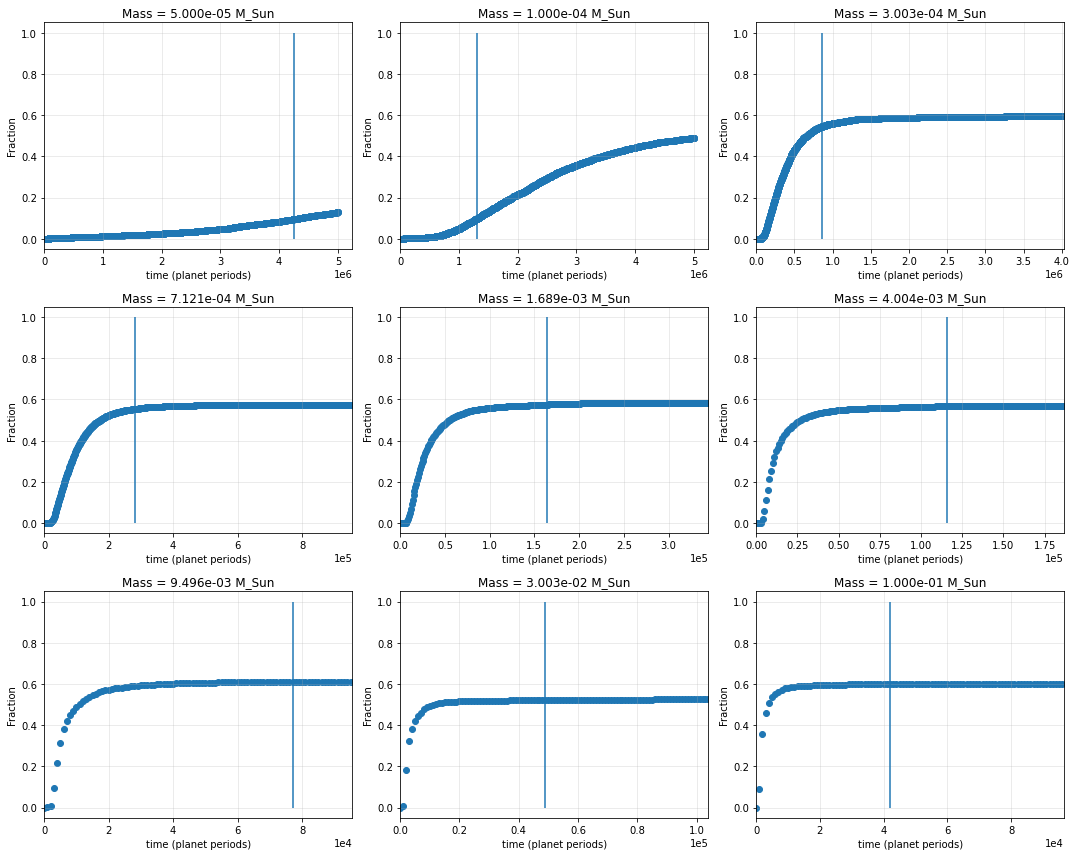

In [29]:
plot_fraction_by_mass(ejection_df)
#plt.savefig('/scratch/group/p.phy260085.000/Mass_Fraction/Outputs/Visualizations/first_aces_run_curves.png')

In [ ]:
ejec_fracs

In [18]:
def time_to_reach_slope_after_peak(fraction_df, targets, dt, mode="below"):

    times = fraction_df.columns.to_numpy(dtype=float)

    cadence = np.median(np.diff(times))
    window = int(round(dt / cadence))

    if window < 1:
        raise ValueError(f"dt={dt} is smaller than the data cadence ({cadence})")
    if not np.isclose(window * cadence, dt, rtol=1e-3):
        print(f"Warning: dt={dt} is not a clean multiple of cadence={cadence}; "
              f"using window={window} steps (~{window * cadence:.3g})")

    result = pd.DataFrame(index=fraction_df.index, columns=targets, dtype=float)
    result['fraction']=np.zeros(len(fraction_df.index))
    for mass in fraction_df.index:
        values = fraction_df.loc[mass].to_numpy(dtype=float)

        if len(values) <= window:
            result.loc[mass, :] = np.nan
            continue

        
        dvalue = values[window:] - values[:-window]
        dtime = times[window:] - times[:-window]
        slope = dvalue / dtime
        slope_times = times[window:]

        peak_idx = np.argmax(slope)
        print(peak_idx)

        search_slope = slope[peak_idx + 1:]
        search_times = slope_times[peak_idx + 1:]


        for target in targets:
            if len(search_slope) == 0:
                result.loc[mass, target] = np.nan
                continue

            if mode == "below":
                condition = search_slope <= target
            elif mode == "above":
                condition = search_slope >= target
            else:
                raise ValueError("mode must be 'below' or 'above'")

            if not condition.any():
                result.loc[mass, target] = np.nan
                continue

            idx = np.argmax(condition)
            result.loc[mass, target] = search_times[idx]

            result['fraction'][mass]=fraction_df.loc[mass, search_times[idx]]

    return result

In [19]:
targets = [0.0000001]
ejection_time_df = time_to_reach_slope_after_peak(ejection_df, targets, 10000)

2540
1059
213
36
12
3
2
0
0


/var/folders/vk/2xktddx11s99wx6wl7rlmm9c0000gn/T/ipykernel_54392/3303949817.py:55: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  result['fraction'][mass]=fraction_df.loc[mass, search_times[idx]]
/var/folders/vk/2xktddx11s99wx6wl7rlmm9c0000gn

In [20]:
ejection_time_df.loc[.1, 1e-7]

42000.0

In [21]:
ejection_time_df['fraction'][.1]

0.5986666666666667

FileNotFoundError: [Errno 2] No such file or directory: '/scratch/group/p.phy260085.000/Mass_Fraction/Outputs/Visualizations/remaining_fraction_table.png'

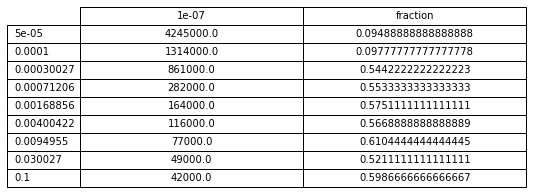

In [22]:
fig, ax = plt.subplots(figsize=(8, 3))
ax.axis("off")

df=ejection_time_df

table = ax.table(
    cellText=df.values,
    colLabels=df.columns,
    rowLabels=df.index,
    cellLoc="center",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.5)

plt.savefig("/scratch/group/p.phy260085.000/Mass_Fraction/Outputs/Visualizations/remaining_fraction_table.png", dpi=300, bbox_inches="tight")
plt.close()

In [ ]:
ejection_time_df

,1e-07,fraction
0.000050,4245000.0,0.094889
0.000100,1314000.0,0.097778
0.000300,861000.0,0.544222
0.000712,282000.0,0.553333
0.001689,164000.0,0.575111
0.004004,116000.0,0.566889
0.009496,77000.0,0.610444
0.030027,49000.0,0.521111
0.100000,42000.0,0.598667


In [ ]:
capture_df

,0.0,1000.0,2000.0,3000.0,4000.0,5000.0,6000.0,7000.0,8000.0,9000.0,...,4972000.0,4976000.0,4977000.0,4981000.0,4982000.0,4984000.0,4991000.0,4993000.0,4994000.0,4995000.0
0.000050,0.000222,0.000444,0.000444,0.000444,0.000667,0.000667,0.000667,0.000667,0.000667,0.000667,...,0.012222,0.012222,0.012222,0.012222,0.012222,0.012222,0.012222,0.012222,0.012222,0.012222
0.000100,0.000667,0.000667,0.000667,0.000889,0.000889,0.001111,0.001333,0.001333,0.001333,0.001333,...,0.009333,0.009333,0.009333,0.009333,0.009333,0.009333,0.009333,0.009333,0.009333,0.009333
0.000300,0.000889,0.001333,0.001333,0.001556,0.001556,0.001556,0.001556,0.001556,0.001556,0.001556,...,0.005778,0.005778,0.005778,0.005778,0.005778,0.005778,0.005778,0.005778,0.005778,0.005778
0.000712,0.001333,0.001333,0.001556,0.001556,0.001778,0.001778,0.001778,0.002000,0.002000,0.002000,...,0.003111,0.003111,0.003111,0.003111,0.003111,0.003111,0.003111,0.003111,0.003111,0.003111
0.001689,0.002889,0.003111,0.003333,0.003333,0.003333,0.003333,0.003556,0.003556,0.003556,0.003556,...,0.004000,0.004000,0.004000,0.004000,0.004000,0.004000,0.004000,0.004000,0.004000,0.004000
0.004004,0.003333,0.003778,0.004222,0.004222,0.004444,0.004889,0.004889,0.004889,0.005111,0.005333,...,0.013111,0.013111,0.013111,0.013111,0.013111,0.013111,0.013111,0.013111,0.013111,0.013111
0.009496,0.004667,0.004667,0.004889,0.005111,0.005111,0.005111,0.005556,0.005778,0.005778,0.005778,...,0.009778,0.009778,0.009778,0.009778,0.009778,0.009778,0.009778,0.009778,0.009778,0.009778
0.030027,0.006889,0.006889,0.007111,0.007111,0.007333,0.007333,0.007333,0.007778,0.008000,0.008222,...,0.015556,0.015556,0.015556,0.015556,0.015556,0.015556,0.015556,0.015556,0.015556,0.015556
0.100000,0.018000,0.019333,0.019778,0.020222,0.020667,0.020667,0.021111,0.022000,0.022444,0.022889,...,0.034667,0.034667,0.034667,0.034667,0.034667,0.034667,0.034667,0.034667,0.034667,0.034667
